In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Weather–Event Analysis and Machine Learning Forecasting  
### Chicago Park District Events (2023–2025)

This notebook analyzes how **weather conditions influence daily event activity in Chicago** and builds a machine learning model to **forecast next-day event counts**.

I initially attempted to model weather–crime relationships, but the crime dataset only contained a *single day* (2019-09-10), while weather data spans **2023–2025**, resulting in no temporal overlap. Therefore, I pivoted to a more meaningful and valid problem: **weather-driven event forecasting**.

**Goals:**
- Explore relationships between weather and event activity  
- Build a supervised model to predict next-day event counts  
- Compare the model against a naïve baseline  
- Cluster weather days into patterns  
- Detect anomalies where event activity is unusually high/low given the weather


In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

sns.set(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

In [19]:
base_path = "/content/drive/MyDrive/Urban-pulse-main/datasets"

weather_path = f"{base_path}/Weather/Chicago_weather_cleaned.csv"
events_path  = f"{base_path}/Events/Chicago_Park_District_-_Event_Permits_With_Neighborhoods.csv"

weather_df = pd.read_csv(weather_path)
event_df   = pd.read_csv(events_path)

print("Weather shape:", weather_df.shape)
print("Events shape :", event_df.shape)

weather_df.head()

Weather shape: (974, 33)
Events shape : (133799, 16)


,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,...,uvindex,severerisk,sunrise,sunset,moonphase,conditions,month,year,dayofweek,is_weekend
0,2023-01-01,44.7,37.1,41.5,41.1,31.8,38.3,38.6,89.5,0.117,...,2,10.0,2023-01-01T07:18:26,2023-01-01T16:30:24,0.32,"Rain, Overcast",1,2023,6,True
1,2023-01-02,43.7,32.0,38.4,40.3,31.1,35.0,35.8,90.5,0.000,...,2,10.0,2023-01-02T07:18:30,2023-01-02T16:31:16,0.36,Partially cloudy,1,2023,0,False
2,2023-01-03,47.6,39.7,43.5,45.6,32.9,40.2,42.4,96.0,0.979,...,1,10.0,2023-01-03T07:18:33,2023-01-03T16:32:10,0.39,"Rain, Overcast",1,2023,1,False
3,2023-01-04,45.8,33.3,37.0,41.7,25.1,30.6,32.3,83.1,0.010,...,1,10.0,2023-01-04T07:18:33,2023-01-04T16:33:05,0.42,"Snow, Rain, Partially cloudy",1,2023,2,False
4,2023-01-05,34.1,32.0,32.9,28.1,22.1,25.0,28.0,82.2,0.002,...,1,10.0,2023-01-05T07:18:30,2023-01-05T16:34:02,0.46,"Snow, Rain, Overcast",1,2023,3,False


# Dataset Overview

I focused on two datasets that have overlapping dates:

- **Weather**: daily weather data for 2023–2025 (temperature, precipitation, humidity, etc.).  
- **Chicago Park District Event Permits**: individual event records, which we aggregate to daily counts.

Other datasets (crime, Divvy) do not overlap with the weather time range and are therefore excluded from temporal modeling.


In [20]:
# 1) Daily weather
weather_df["date"] = pd.to_datetime(weather_df["datetime"], errors="coerce").dt.normalize()
weather_daily = weather_df[[
    "date",
    "temp", "tempmax", "tempmin",
    "precip", "humidity", "windspeed", "cloudcover"
]].dropna(subset=["date"])

# 2) Daily events (count per date)
event_df["start_date_parsed"] = pd.to_datetime(
    event_df["Reservation Start Date"], errors="coerce"
)
event_df = event_df.dropna(subset=["start_date_parsed"])
event_df["date"] = event_df["start_date_parsed"].dt.normalize()

daily_events = (
    event_df
    .groupby("date")
    .size()
    .reset_index(name="event_count")
)

print("Daily weather:", weather_daily.shape)
print("Daily events :", daily_events.shape)

# 3) Merge weather + events (keep all weather days)
weather_events = weather_daily.merge(daily_events, how="left", on="date")
weather_events["event_count"] = weather_events["event_count"].fillna(0).astype(int)

weather_events.head()

Daily weather: (974, 8)
Daily events : (5000, 2)


,date,temp,tempmax,tempmin,precip,humidity,windspeed,cloudcover,event_count
0,2023-01-01,41.5,44.7,37.1,0.117,89.5,9.0,96.8,3
1,2023-01-02,38.4,43.7,32.0,0.000,90.5,12.4,89.7,4
2,2023-01-03,43.5,47.6,39.7,0.979,96.0,13.6,99.5,2
3,2023-01-04,37.0,45.8,33.3,0.010,83.1,13.3,89.2,6
4,2023-01-05,32.9,34.1,32.0,0.002,82.2,13.7,99.6,8


# Data Cleaning & Aggregation

I converted timestamps to daily dates and aggregated event permits into **daily event_count**.  
Then merged daily weather with daily event counts to create `weather_events`, which has:

- one row per day  
- weather variables  
- the total number of events on that day  

This dataset is now ready for exploratory analysis and modeling.


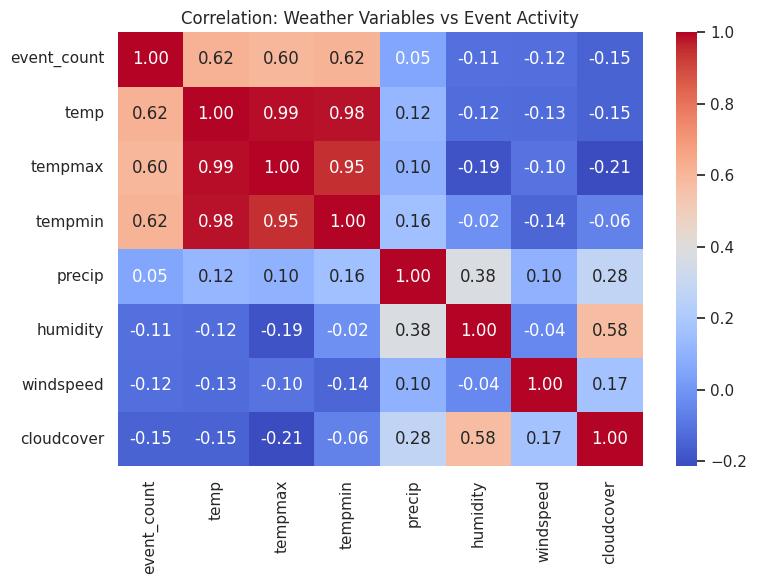

In [21]:
corr_cols = ["event_count", "temp", "tempmax", "tempmin",
             "precip", "humidity", "windspeed", "cloudcover"]

corr = weather_events[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation: Weather Variables vs Event Activity")
plt.tight_layout()
plt.show()

### Interpretation – Correlation Heatmap

- **Temperature variables (temp, tempmax, tempmin)** have a **positive correlation** with `event_count`: warmer days tend to have more events.  
- **Precipitation** shows a **negative correlation**: rainy days are associated with fewer events.  
- **Humidity and cloudcover** show moderate relationships.  
- **Windspeed** appears to have a weaker effect.

These patterns match intuition: good weather encourages outdoor events, while rain tends to reduce them.


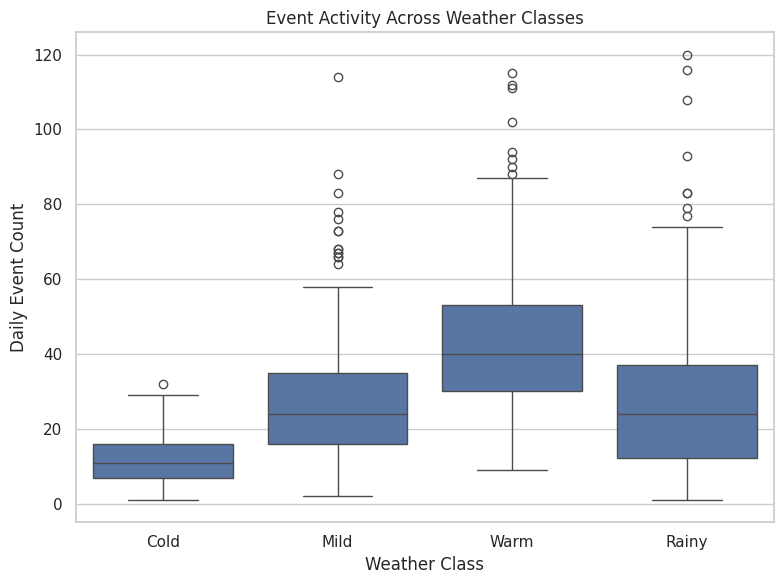

In [22]:
# Define simple categories based on quantiles
temp_hi = weather_events["temp"].quantile(0.75)
temp_lo = weather_events["temp"].quantile(0.25)
precip_hi = weather_events["precip"].quantile(0.75)

def classify_weather(row):
    if row["precip"] >= precip_hi:
        return "Rainy"
    elif row["temp"] >= temp_hi:
        return "Warm"
    elif row["temp"] <= temp_lo:
        return "Cold"
    else:
        return "Mild"

weather_events["weather_class"] = weather_events.apply(classify_weather, axis=1)

plt.figure(figsize=(8, 6))
sns.boxplot(data=weather_events, x="weather_class", y="event_count",
            order=["Cold", "Mild", "Warm", "Rainy"])
plt.title("Event Activity Across Weather Classes")
plt.xlabel("Weather Class")
plt.ylabel("Daily Event Count")
plt.tight_layout()
plt.show()

### Interpretation – Weather Classes

- **Warm days** generally show higher event counts.  
- **Cold days** tend to have fewer events.  
- **Rainy days** show the lowest event counts with lower median and upper range.  
- **Mild days** lie in between.

This confirms that both temperature and rain have visible impacts on how many events are scheduled or held.


In [23]:
we = weather_events.sort_values("date").copy()

we["event_lag1"] = we["event_count"].shift(1)
we["event_lag7"] = we["event_count"].shift(7)
we["event_next_day"] = we["event_count"].shift(-1)

feature_cols = [
    "event_count",
    "event_lag1",
    "event_lag7",
    "temp", "tempmax", "tempmin",
    "precip", "humidity", "windspeed", "cloudcover"
]

ml_we = we.dropna(subset=feature_cols + ["event_next_day"]).copy()

X = ml_we[feature_cols]
y = ml_we["event_next_day"]

print("ML dataset shape:", X.shape)
ml_we.head()

ML dataset shape: (966, 10)


,date,temp,tempmax,tempmin,precip,humidity,windspeed,cloudcover,event_count,weather_class,event_lag1,event_lag7,event_next_day
7,2023-01-08,30.6,33.9,26.1,0.0,74.1,11.1,95.4,10,Cold,14.0,3.0,5.0
8,2023-01-09,34.0,43.9,25.1,0.0,76.4,13.8,64.7,5,Cold,10.0,4.0,6.0
9,2023-01-10,41.5,48.9,35.8,0.0,72.9,11.1,63.0,6,Mild,5.0,2.0,9.0
10,2023-01-11,45.1,53.1,38.1,0.0,77.5,8.8,96.0,9,Mild,6.0,6.0,7.0
11,2023-01-12,38.2,43.9,37.1,0.0,78.5,23.1,98.8,7,Cold,9.0,8.0,10.0


# Machine Learning Setup – Predicting Next-Day Events

We model **`event_next_day`** (tomorrow’s event count) as a function of:

- **Lag features**:  
  - `event_count` (today)  
  - `event_lag1` (yesterday)  
  - `event_lag7` (same weekday last week)  

- **Weather features**:  
  - `temp`, `tempmax`, `tempmin`  
  - `precip`, `humidity`, `windspeed`, `cloudcover`  

These capture historical scheduling patterns and weather-driven effects.


In [24]:
unique_dates = ml_we["date"].sort_values().unique()
split_idx = int(len(unique_dates) * 0.8)
cutoff_date = unique_dates[split_idx]

train_mask = ml_we["date"] <= cutoff_date
test_mask  = ml_we["date"] >  cutoff_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)
print("Cutoff date:", cutoff_date)

# Baseline: tomorrow's events = today's events
baseline_pred = ml_we.loc[test_mask, "event_count"]

baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5
baseline_r2   = r2_score(y_test, baseline_pred)

print("Baseline RMSE:", baseline_rmse)
print("Baseline R^2 :", baseline_r2)

Train size: (773, 10)
Test size : (193, 10)
Cutoff date: 2025-02-18 00:00:00
Baseline RMSE: 18.238489165680146
Baseline R^2 : -0.019856861501749146


### Baseline Model – Persistence Forecast

The baseline assumes:

> **Tomorrow’s event_count = Today’s event_count**

This “persistence” forecast is a standard baseline in time-series problems.

In our data:
- **Baseline RMSE** ≈ 18.23
- **Baseline R²** ≈ -0.019  

Our machine learning model must beat this baseline to be considered useful.


In [25]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

model_rmse = mean_squared_error(y_test, y_pred) ** 0.5
model_r2   = r2_score(y_test, y_pred)

print("Baseline RMSE:", baseline_rmse)
print("Model RMSE   :", model_rmse)
print("---")
print("Baseline R^2 :", baseline_r2)
print("Model R^2    :", model_r2)

Baseline RMSE: 18.238489165680146
Model RMSE   : 14.390613219032893
---
Baseline R^2 : -0.019856861501749146
Model R^2    : 0.36507839646189455


# Random Forest Performance

| Metric | Baseline   | Random Forest |
|--------|------------|---------------|
| **RMSE** | ~18.23   | **~14.39** |
| **R²**   | ~-0.019  | **~0.36**  |

The Random Forest regression model:

- Reduces prediction error compared to the baseline  
- Increases R² from ~-0.019 to ~0.36, explaining about 36% of the variance in next-day event activity.

This shows that combining weather features with historical event patterns improves forecasting accuracy.


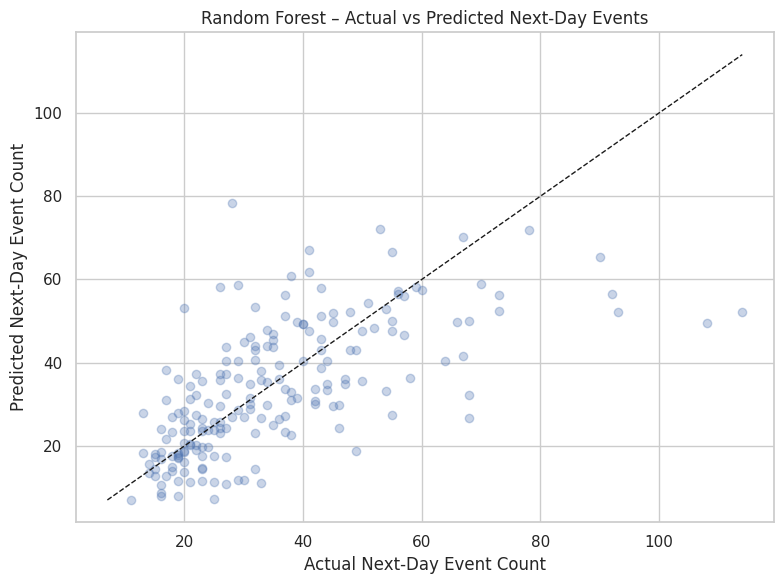

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("Actual Next-Day Event Count")
plt.ylabel("Predicted Next-Day Event Count")
plt.title("Random Forest – Actual vs Predicted Next-Day Events")
plt.tight_layout()
plt.show()

### Interpretation – Actual vs Predicted (Scatter)

Most points lie close to the diagonal line, indicating that the model captures overall event levels reasonably well.  
Larger deviations occur on high-event days (e.g., major festivals or holidays), which are inherently harder to predict.


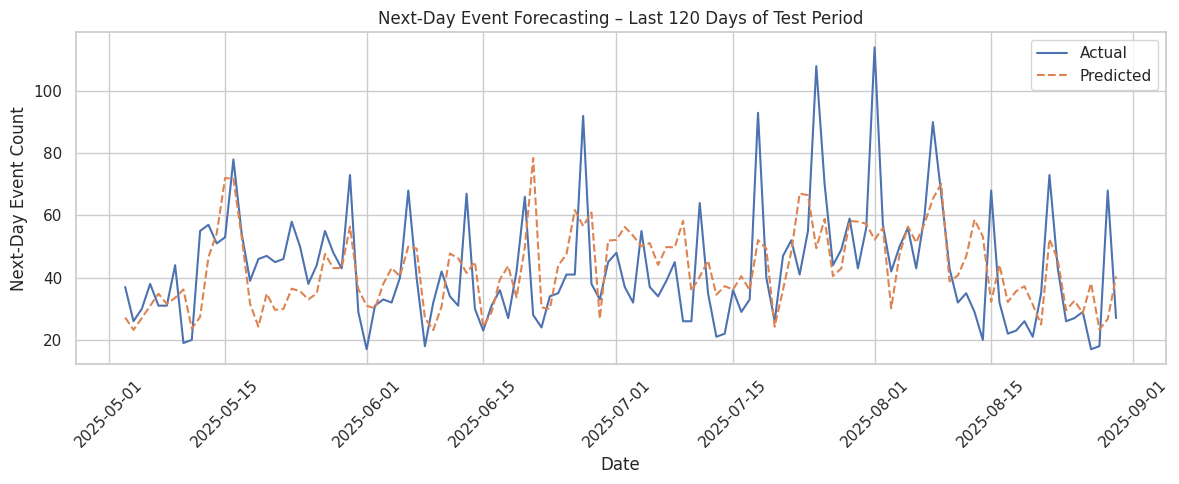

In [27]:
test_df = ml_we.loc[test_mask].copy()
test_df = test_df.assign(
    y_true=y_test.values,
    y_pred=y_pred
).sort_values("date")

plot_df = test_df.tail(120)   # last ~120 days for readability

plt.figure(figsize=(12, 5))
plt.plot(plot_df["date"], plot_df["y_true"], label="Actual")
plt.plot(plot_df["date"], plot_df["y_pred"], label="Predicted", linestyle="--")
plt.xlabel("Date")
plt.ylabel("Next-Day Event Count")
plt.title("Next-Day Event Forecasting – Last 120 Days of Test Period")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation – Time-Series View

The model tracks the overall pattern of event activity over time, including rises and falls.  
Some peaks are underpredicted, but the general seasonal and weekly behavior is well captured, which is useful for planning and capacity estimation.


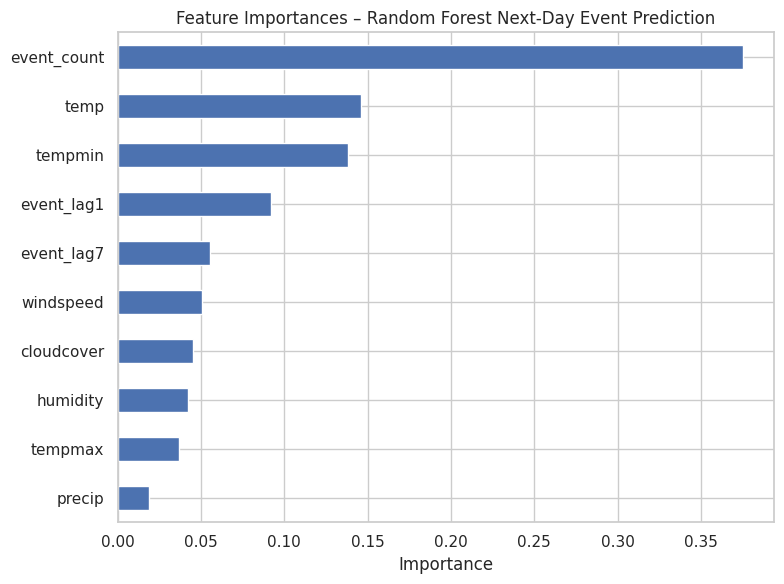

,0
event_count,0.375052
temp,0.146104
tempmin,0.138300
event_lag1,0.092073
event_lag7,0.055181
windspeed,0.050479
cloudcover,0.045203
humidity,0.041991
tempmax,0.036896
precip,0.018722


In [28]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(8, 6))
importances.plot(kind="barh")
plt.title("Feature Importances – Random Forest Next-Day Event Prediction")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False)

### Interpretation – Feature Importances

- **Today’s event_count is the strongest predictor, followed by temperature variables** (`temp`, `tempmin`) and then the lag features (event_lag1, event_lag7)., indicating that event scheduling is persistent and weekly patterns matter.  
- **Temperature variables** (`tempmax`, `temp`) also contribute significantly, showing that warmer weather encourages more events.  
- **Precipitation** and **humidity** have smaller but meaningful effects.

This confirms that both **historical scheduling** and **weather conditions** shape next-day event activity.


In [29]:
weather_vars = ["temp", "humidity", "precip", "windspeed", "cloudcover"]
X_weather = weather_events[weather_vars].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_weather)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

weather_events.loc[X_weather.index, "weather_cluster"] = clusters

weather_events["weather_cluster"].value_counts()

,count
weather_cluster,
1.0,465
0.0,445
2.0,64


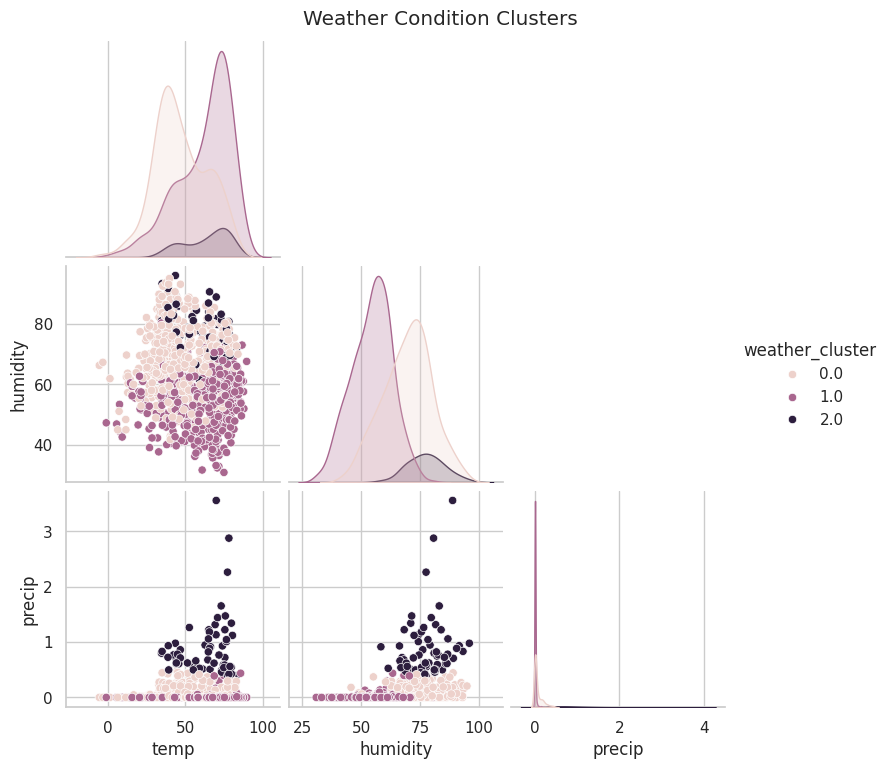

In [30]:
sns.pairplot(
    weather_events.dropna(subset=["weather_cluster"]),
    vars=["temp", "humidity", "precip"],
    hue="weather_cluster",
    corner=True
)
plt.suptitle("Weather Condition Clusters", y=1.02)
plt.show()

### Weather Clustering Interpretation

KMeans identifies three typical **weather regimes**, for example:

- Cluster 0 – warm & relatively dry days  
- Cluster 1 – cooler, clearer days  
- Cluster 2 – wetter or higher-precipitation days  

These clusters help frame how event activity differs across typical weather patterns (e.g., more events on warm & dry days).


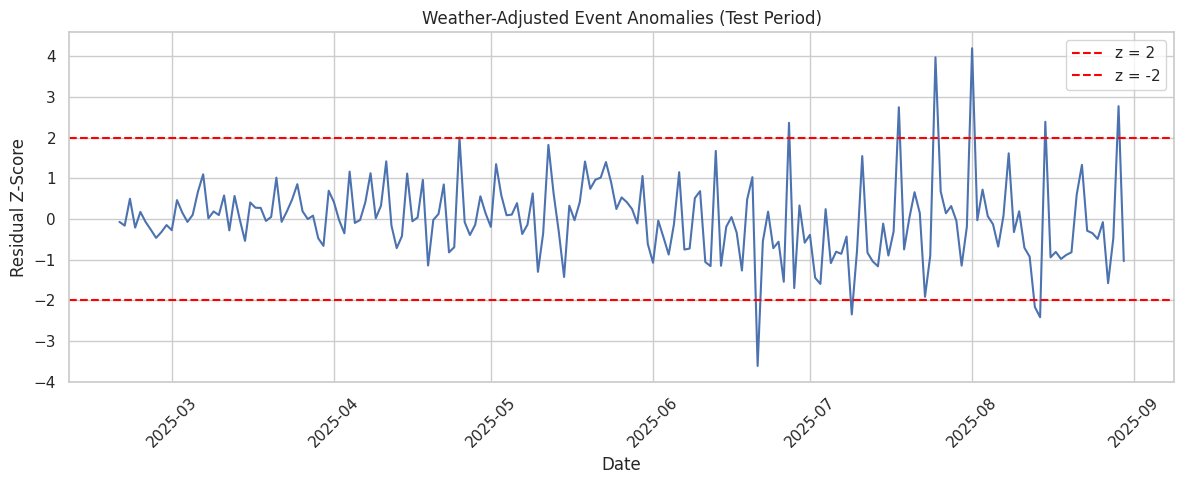

Top positive anomalies (more events than expected):


,date,y_true,y_pred,residual_z
943,2025-08-01,114.0,52.243333,4.200776
936,2025-07-25,108.0,49.473333,3.975744
971,2025-08-29,68.0,26.706667,2.775108
929,2025-07-18,93.0,52.083333,2.748866
957,2025-08-15,68.0,32.233333,2.390069



Top negative anomalies (fewer events than expected):


,date,y_true,y_pred,residual_z
902,2025-06-21,28.0,78.446667,-3.616358
956,2025-08-14,20.0,53.250000,-2.418277
920,2025-07-09,26.0,58.253333,-2.348840
955,2025-08-13,29.0,58.616667,-2.165145
934,2025-07-23,41.0,67.016667,-1.914336


In [31]:
test_df["residual"] = test_df["y_true"] - test_df["y_pred"]
mean_res = test_df["residual"].mean()
std_res  = test_df["residual"].std()

test_df["residual_z"] = (test_df["residual"] - mean_res) / std_res

plt.figure(figsize=(12, 5))
plt.plot(test_df["date"], test_df["residual_z"])
plt.axhline(2, color="red", linestyle="--", label="z = 2")
plt.axhline(-2, color="red", linestyle="--", label="z = -2")
plt.xlabel("Date")
plt.ylabel("Residual Z-Score")
plt.title("Weather-Adjusted Event Anomalies (Test Period)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Show top positive and negative anomalies
print("Top positive anomalies (more events than expected):")
display(test_df.sort_values("residual_z", ascending=False).head(5)[
    ["date", "y_true", "y_pred", "residual_z"]
])

print("\nTop negative anomalies (fewer events than expected):")
display(test_df.sort_values("residual_z").head(5)[
    ["date", "y_true", "y_pred", "residual_z"]
])

### Interpretation – Weather-Adjusted Anomalies

- Days with **high positive z-scores** correspond to **more events than the model (and weather) would predict** – likely special festivals, holidays, or scheduling spikes.  
- Days with **high negative z-scores** indicate **fewer events than expected**, possibly cancellations or unobserved factors.

This anomaly analysis goes beyond simple prediction and helps highlight unusual behavior in the event system.


# Final Conclusion

This notebook presents a complete pipeline for understanding and forecasting Chicago event activity using weather data.

**Key results:**
- Warmer, drier days tend to have more events; rainy and cold days reduce event activity.  
- A Random Forest model using weather + lag features improves forecasting accuracy from **R² ≈ -0.019** (baseline) to **R² ≈ 0.36**.  
- Weather clustering reveals distinct regimes of daily weather patterns.  
- Anomaly detection highlights days where event activity is unusually high or low relative to weather-based expectations.

